<a href="https://colab.research.google.com/github/Jagadeesh819/aiml/blob/main/Student_carrerpath2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np

In [22]:
data = []
for i in range(300):
    maths = np.random.randint(40, 100)
    science = np.random.randint(40, 100)
    english = np.random.randint(40, 100)

    coding = np.random.randint(0, 2)
    creativity = np.random.randint(0, 2)
    communication = np.random.randint(0, 2)

    if maths > 80 and science > 80 and coding == 1:
        career = "Engineer"
    elif science > 85 and maths > 75:
        career = "Doctor"
    elif coding == 1 and maths > 75:
        career = "Data Scientist"
    elif creativity == 1 and english > 70:
        career = "Artist"
    elif communication == 1 and english > 75:
        career = "Business"
    else:
        career = "Other"

    data.append([maths, science, english, coding, creativity, communication, career])

In [23]:
df = pd.DataFrame(data, columns=[
    "Maths", "Science", "English",
    "Coding", "Creativity", "Communication",
    "Career"
])
print(df.head())

   Maths  Science  English  Coding  Creativity  Communication          Career
0     79       82       49       0           0              1           Other
1     64       55       80       1           1              0          Artist
2     56       58       91       1           1              1          Artist
3     87       56       90       1           0              0  Data Scientist
4     96       49       61       0           0              0           Other


In [24]:
df.to_csv("career_dataset.csv", index=False)
print("Dataset saved succesfully")

df = pd.read_csv("career_dataset.csv")
print(df.head())

Dataset saved succesfully
   Maths  Science  English  Coding  Creativity  Communication          Career
0     79       82       49       0           0              1           Other
1     64       55       80       1           1              0          Artist
2     56       58       91       1           1              1          Artist
3     87       56       90       1           0              0  Data Scientist
4     96       49       61       0           0              0           Other


In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Career'] = le.fit_transform(df['Career'])

In [26]:
X = df.drop('Career', axis=1)
y = df['Career']

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dense(32, activation='relu'),
    Dense(len(set(y)), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2542 - loss: 1.7305 - val_accuracy: 0.4000 - val_loss: 1.6400
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5792 - loss: 1.4344 - val_accuracy: 0.4500 - val_loss: 1.4379
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5667 - loss: 1.2066 - val_accuracy: 0.4333 - val_loss: 1.2941
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5625 - loss: 1.0481 - val_accuracy: 0.4667 - val_loss: 1.1947
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6208 - loss: 0.9209 - val_accuracy: 0.5333 - val_loss: 1.0640
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6875 - loss: 0.8136 - val_accuracy: 0.5667 - val_loss: 0.9605
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7542 - loss: 0.7273 - val_accuracy: 0.6667 - val_loss: 0.8646
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8042 - loss: 0.6508 - val_accuracy: 0.7000 - val_loss

In [32]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8667 - loss: 0.2930
Accuracy: 0.8666666746139526


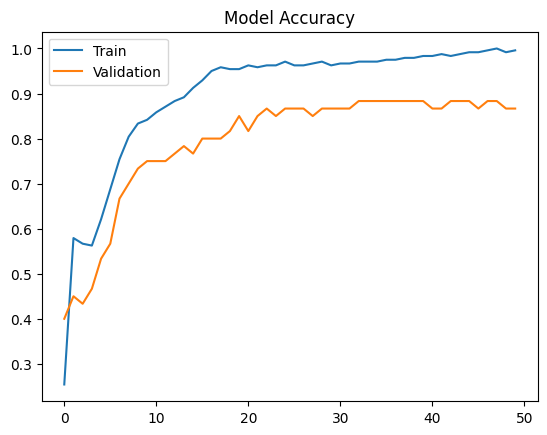

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [34]:
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [35]:

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_classes))
print(confusion_matrix(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82        12
           1       1.00      1.00      1.00         4
           2       0.80      1.00      0.89        12
           3       0.50      0.75      0.60         4
           4       1.00      0.25      0.40         4
           5       0.96      0.96      0.96        24

    accuracy                           0.87        60
   macro avg       0.86      0.78      0.78        60
weighted avg       0.89      0.87      0.86        60

[[ 9  0  0  2  0  1]
 [ 0  4  0  0  0  0]
 [ 0  0 12  0  0  0]
 [ 1  0  0  3  0  0]
 [ 0  0  3  0  1  0]
 [ 0  0  0  1  0 23]]


In [36]:
sample = [[85, 80, 75, 1, 0, 1]]

sample = scaler.transform(sample)

pred = model.predict(sample)

print("Predicted Career:", le.inverse_transform([pred.argmax()]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Career: ['Engineer']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
